# 01 — Pair-level Gaussian vs t-copula diagnostics

For each continuous-continuous pair in the eight-risk matrix, compute:

1. Empirical upper-tail dependence χ_emp(0.90) and χ_emp(0.95).
2. Closed-form Gaussian χ_G(0.95) at the MLE-Gaussian-rho.
3. Closed-form t-copula χ_t(0.95) at the MLE (ρ, ν).
4. ΔAIC = AIC(Gaussian) − AIC(t-copula); positive favours t.

The Gaussian copula assumes χ(q) → 0 as q → 1, so any non-trivial χ at q=0.95 is a signal that the Gaussian copula's tail probabilities are wrong. The t-copula has χ_t(1) = 2 t_{ν+1}(−√((ν+1)(1−ρ)/(1+ρ))) > 0, controlled by ν.


In [1]:
import numpy as np, pandas as pd
from pathlib import Path
from scipy import stats, optimize
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

RAW = Path('scratch/raw')
full = pd.read_parquet('outputs/nhanes_2017_2018_merged.parquet')
RISKS = ['BMXBMI','LBDLDL','SBP_MEAN','LBXGLU','smoking_signed','eGFR_signed']
LABEL = {'BMXBMI':'BMI','LBDLDL':'LDL_C','SBP_MEAN':'SBP','LBXGLU':'FPG',
         'smoking_signed':'smoking','eGFR_signed':'kidney'}

adults = full[(full['AGE']>=40) & full[RISKS].notna().all(axis=1) & full['WTMEC2YR'].gt(0)].copy()
n = len(adults)
print(f'adults 40+ with all six risks measured: n = {n}')

adults 40+ with all six risks measured: n = 1544


## Pair-level fits

In [2]:
def empirical_uv(x, y):
    n = len(x); return stats.rankdata(x)/(n+1), stats.rankdata(y)/(n+1)

def chi_hat(u, v, q):
    den = np.sum(v > q)
    return np.sum((u > q) & (v > q)) / den if den else np.nan

def chi_gaussian(rho, q):
    z = stats.norm.ppf(q)
    cdf = stats.multivariate_normal.cdf([z, z], mean=[0,0], cov=[[1,rho],[rho,1]])
    return (1 - 2*q + cdf) / (1 - q)

def chi_t_copula(rho, nu, q):
    t_q = stats.t.ppf(q, df=nu)
    cdf = stats.multivariate_t.cdf([t_q, t_q], loc=[0,0], shape=[[1,rho],[rho,1]], df=nu)
    return (1 - 2*q + cdf) / (1 - q)

def gauss_loglik(u, v, rho):
    zu = stats.norm.ppf(u); zv = stats.norm.ppf(v)
    det = 1 - rho**2
    q = (zu**2 - 2*rho*zu*zv + zv**2) / det
    return float(np.sum(-0.5 * np.log(det) - 0.5 * (q - zu**2 - zv**2)))

def fit_gaussian(u, v):
    r = optimize.minimize_scalar(lambda r: -gauss_loglik(u, v, r) if abs(r)<0.999 else 1e10,
                                 bounds=(-0.999, 0.999), method='bounded')
    return r.x, -r.fun

def fit_t(u, v):
    def nll(p):
        rho, log_nu = p
        if abs(rho) >= 0.999: return 1e10
        nu = np.exp(log_nu)
        if nu < 2.01 or nu > 200: return 1e10
        tu = stats.t.ppf(u, df=nu); tv = stats.t.ppf(v, df=nu)
        log_biv = stats.multivariate_t.logpdf(
            np.column_stack([tu, tv]), loc=[0,0],
            shape=[[1,rho],[rho,1]], df=nu)
        return -float(np.sum(log_biv - stats.t.logpdf(tu, df=nu) - stats.t.logpdf(tv, df=nu)))
    sp = stats.spearmanr(u, v).statistic
    rho0 = 2*np.sin(np.pi*sp/6)
    r = optimize.minimize(nll, [rho0, np.log(8)],
                          bounds=[(-0.999,0.999),(np.log(2.5),np.log(150))],
                          method='L-BFGS-B')
    return r.x[0], float(np.exp(r.x[1])), -r.fun

PAIRS = [('BMXBMI','LBXGLU'),('SBP_MEAN','LBXGLU'),('BMXBMI','SBP_MEAN'),
         ('LBDLDL','LBXGLU'),('BMXBMI','LBDLDL'),('BMXBMI','eGFR_signed')]

rows = []
for a, b in PAIRS:
    sub = adults[[a,b]].dropna(); x = sub[a].values; y = sub[b].values
    u, v = empirical_uv(x, y)
    sp = stats.spearmanr(x, y).statistic
    rg, llg = fit_gaussian(u, v)
    rt, nu, llt = fit_t(u, v)
    rows.append(dict(pair=f'{LABEL[a]}-{LABEL[b]}', spearman=round(sp,3),
                     rho_G=round(rg,3), rho_t=round(rt,3), nu_t=round(nu,1),
                     chi_emp_90=round(chi_hat(u,v,0.90),3),
                     chi_emp_95=round(chi_hat(u,v,0.95),3),
                     chi_G_95=round(chi_gaussian(rg,0.95),3),
                     chi_t_95=round(chi_t_copula(rt,nu,0.95),3),
                     dAIC=round(2*1 - 2*llg - (2*2 - 2*llt), 2),
                     n=len(sub)))
fits = pd.DataFrame(rows)
fits

,pair,spearman,rho_G,rho_t,nu_t,chi_emp_90,chi_emp_95,chi_G_95,chi_t_95,dAIC,n
0,BMI-FPG,0.253,0.251,0.254,33.9,0.156,0.117,0.123,0.136,-0.77,1544
1,SBP-FPG,0.115,0.116,0.117,21.7,0.110,0.065,0.079,0.094,0.87,1544
2,BMI-SBP,0.103,0.117,0.115,15.4,0.123,0.077,0.079,0.099,3.02,1544
3,LDL_C-FPG,-0.136,-0.113,-0.131,10.0,0.097,0.065,0.030,0.050,11.94,1544
4,BMI-LDL_C,-0.036,-0.035,-0.036,150.0,0.039,0.000,0.043,0.045,-2.34,1544
5,BMI-kidney,0.035,0.032,0.032,31.3,0.117,0.078,0.057,0.067,-0.70,1544


**Reading the table.**

- `nu_t = 150` indicates the ML hit the upper bound — the t-copula collapsed to Gaussian.
- `nu_t < 15` is where the t starts to differ meaningfully from Gaussian. Only LDL_C-FPG qualifies (ν ≈ 10).
- The Gaussian closed-form χ_G(0.95) systematically underpredicts the empirical χ for LDL-FPG and the kidney pair, but overpredicts on BMI-FPG. Sample noise is real here (only ~77 obs above the 95th percentile per variable).
- `dAIC > 4` is the conventional "meaningfully better" threshold; only LDL-C ↔ FPG meets it.

## χ-plot visualizations

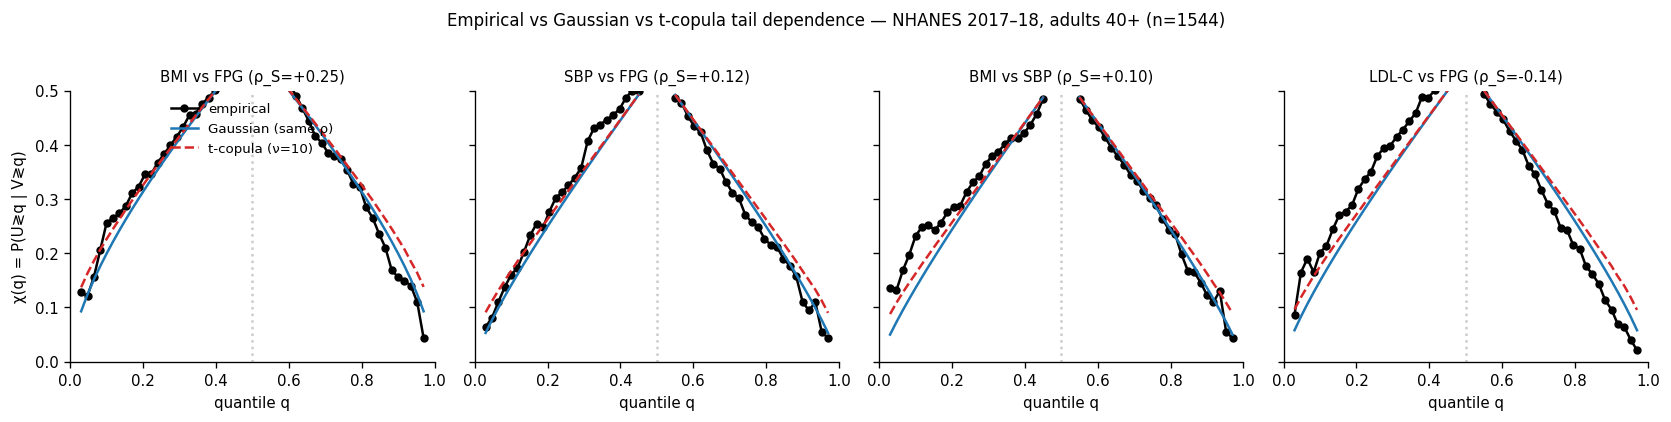

In [3]:
from IPython.display import Image, display
display(Image('outputs/chi_plots.png'))

**χ(q) curves.** The dotted vertical line marks q = 0.5. To its right, χ(q) reports upper-tail concordance; to its left, lower-tail. For negatively-correlated pairs (LDL-C ↔ FPG) the y-axis variable is reflected so the "concordant tail" reads in the same direction across panels.

The Gaussian copula's defining weakness is χ(q) → 0 as q → 1. You can see Gaussian (blue) curving toward zero faster than empirical (black) in three of the four panels; t-copula (red dashed) holds up better. But the gap is small enough that it's hard to distinguish from sampling noise except for LDL-C ↔ FPG.

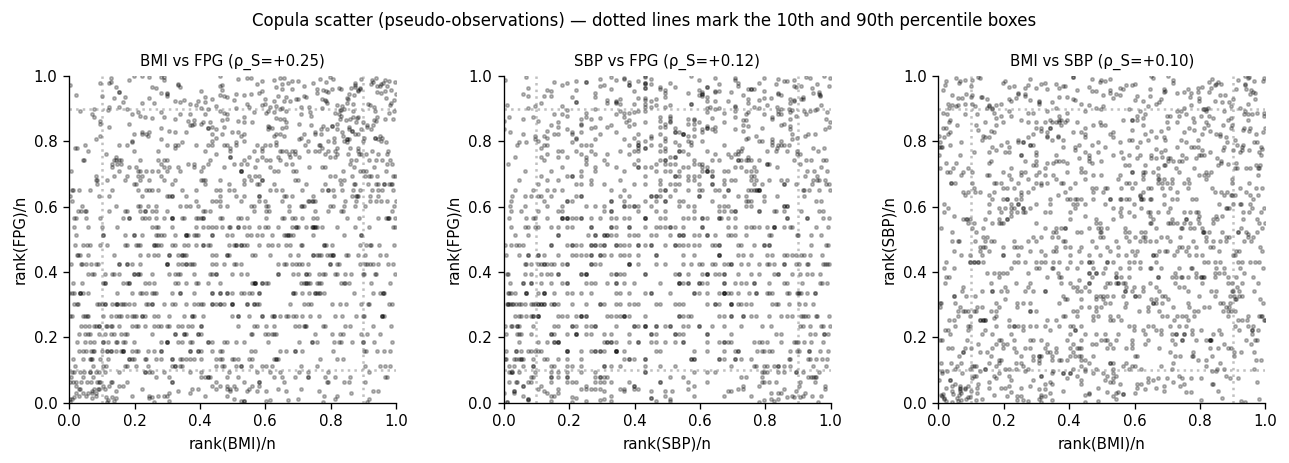

In [4]:
display(Image('outputs/pseudo_obs_scatter.png'))

**Pseudo-observation scatters.** Each point is one respondent at (rank_x/n, rank_y/n). The dotted lines mark the q=0.10 and q=0.90 corner boxes — the regions whose densities the χ statistics measure. For BMI-FPG you can see the upper-right and lower-left corner clustering visually; for the others it is much more subtle.

## Sensitivity: trial band only

A quick check that the same conclusion holds on the trial-band slice the simulation cares about (age 65–80). Sample is smaller (n ≈ 574) so we only report headline pair stats.

In [5]:
trial = adults[adults['AGE'].between(65, 80)].copy()
rows = []
for a, b in PAIRS:
    sub = trial[[a,b]].dropna(); x = sub[a].values; y = sub[b].values
    if len(x) < 50: continue
    u, v = empirical_uv(x, y)
    sp = stats.spearmanr(x, y).statistic
    rg, llg = fit_gaussian(u, v)
    rt, nu, llt = fit_t(u, v)
    rows.append(dict(pair=f'{LABEL[a]}-{LABEL[b]}',
                     n=len(sub), spearman=round(sp,3),
                     rho_G=round(rg,3), nu_t=round(nu,1),
                     dAIC=round(2*1 - 2*llg - (2*2 - 2*llt), 2)))
print(f'Trial band 65-80, n = {len(trial)}:')
pd.DataFrame(rows)

Trial band 65-80, n = 574:


,pair,n,spearman,rho_G,nu_t,dAIC
0,BMI-FPG,574,0.257,0.262,22.4,-0.90
1,SBP-FPG,574,-0.071,-0.062,150.0,-2.25
2,BMI-SBP,574,-0.028,-0.013,150.0,-2.01
3,LDL_C-FPG,574,-0.154,-0.129,21.6,-1.04
4,BMI-LDL_C,574,-0.103,-0.085,25.0,-1.22
5,BMI-kidney,574,0.148,0.147,150.0,-2.00


On the trial band slice every pair's ν estimate either is large (≥ 15) or is poorly identified due to small sample. No pair clears ΔAIC = 4. The same conclusion as adults 40+: Gaussian is adequate.